В этом блокноте представлена демонстрация работы с небольшим фрагментом датасета GraspClutter6D. Сам датасет очень большой, весит > 200 ГБ. Он содержит множество сцен, в качестве примера взята 1 сцена - dataset_fragment (example)

In [1]:
!source .venv/bin/activate && python --version && pip --version

Python 3.13.5
pip 25.1.1 from /home/vladimir/Документы/Проекты/Личные/defects_detection/.venv/lib/python3.13/site-packages/pip (python 3.13)


In [2]:
!pip install -r requirements.txt

Примеры изображений из GraspClutter6D

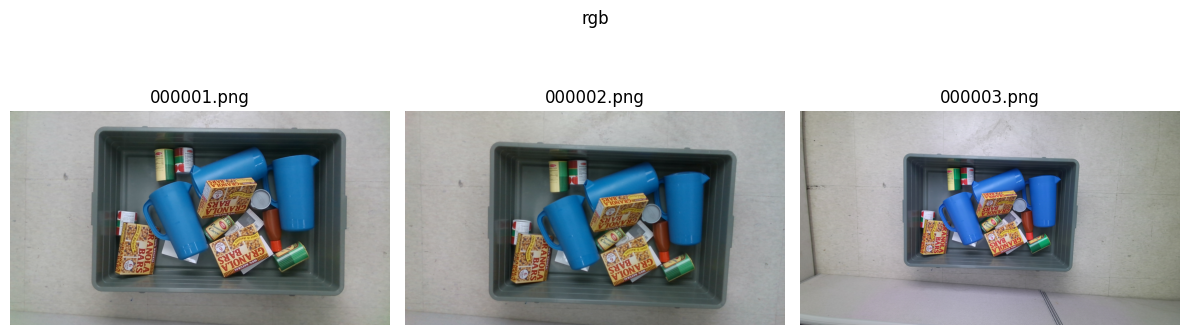

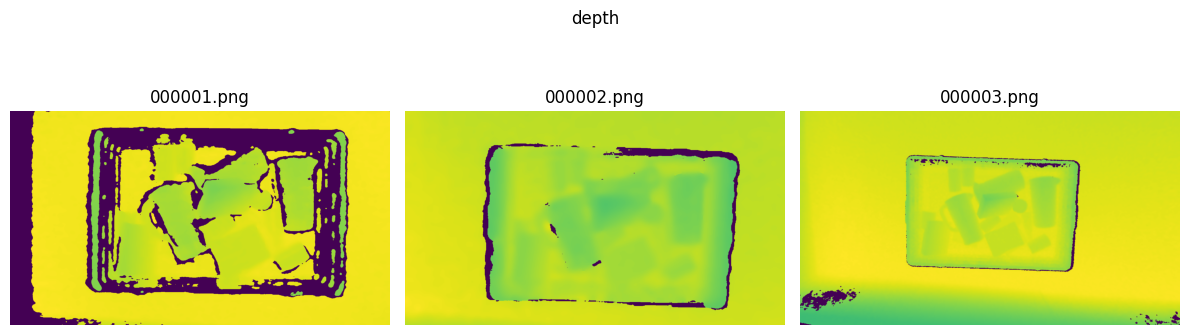

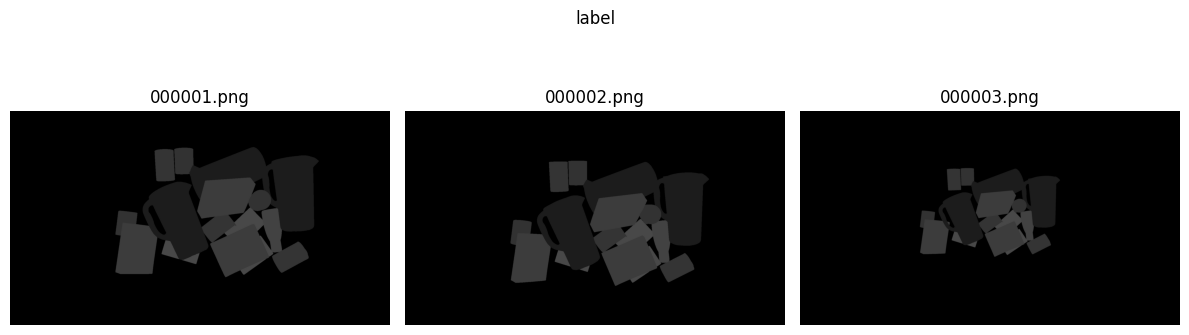

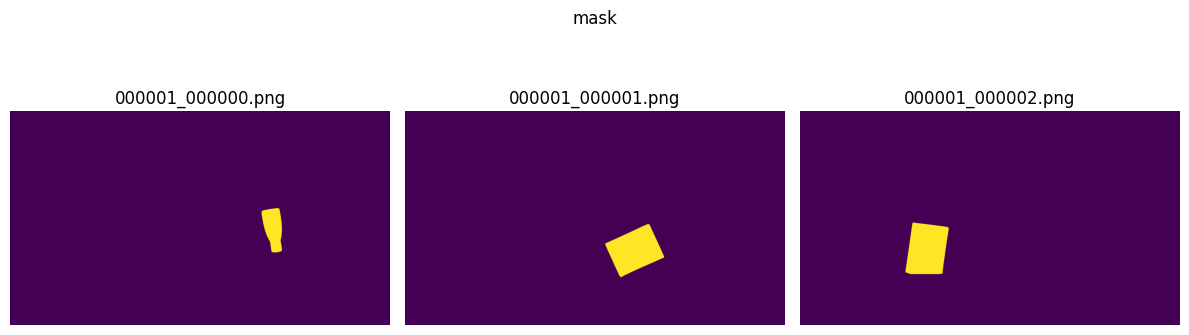

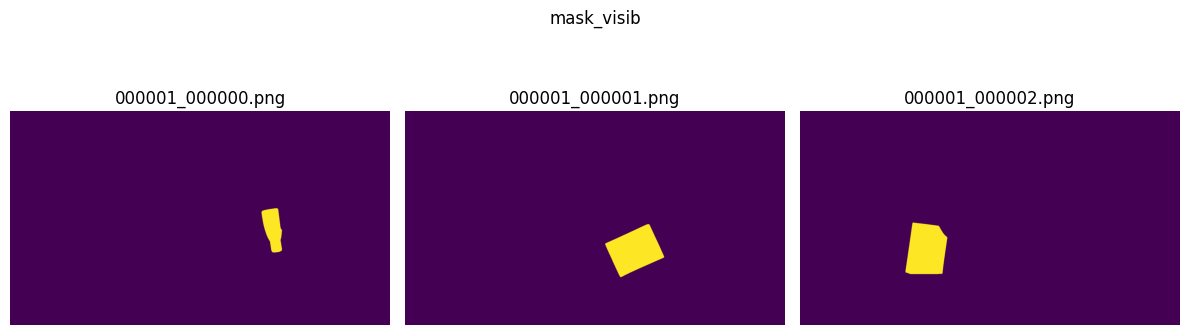

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

base = Path("dataset_fragment (example)")
folders = ["rgb", "depth", "label", "mask", "mask_visib"]

for folder in folders:
    files = sorted((base / folder).glob("*.png"))[:3]
    fig, axes = plt.subplots(1, len(files), figsize=(12, 4))
    if len(files) == 1:
        axes = [axes]
    fig.suptitle(folder)
    for ax, img_path in zip(axes, files):
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Для одного кадра (одинаковое имя файла в rgb и depth) вывод значений -
форма массива, dtype, минимум/максимум значений пикселей. Для depth дополнительно показан диапазон по «валидным» пикселям (> 0), если фон кодируется нулём


In [15]:
from pathlib import Path

import cv2
import numpy as np

base = Path("dataset_fragment (example)")
rgb_path = sorted((base / "rgb").glob("*.png"))[0]
depth_path = base / "depth" / rgb_path.name

rgb = cv2.cvtColor(cv2.imread(str(rgb_path), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
depth = cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED)

print(f"Кадр: {rgb_path.name}\n")

print("RGB:")
print(f"  shape: {rgb.shape}, dtype: {rgb.dtype}")
print(f"  min / max: {rgb.min()}, {rgb.max()}")

print("\nDepth:")
print(f"  shape: {depth.shape}, dtype: {depth.dtype}")
print(f"  min / max (все пиксели): {depth.min()}, {depth.max()}")
if depth.ndim == 2 and np.any(depth > 0):
    v = depth[depth > 0]
    print(f"  min / max (depth > 0): {v.min()}, {v.max()}")


Кадр: 000001.png

RGB:
  shape: (1080, 1920, 3), dtype: uint8
  min / max: 0, 255

Depth:
  shape: (1080, 1920), dtype: uint16
  min / max (все пиксели): 0, 1028
  min / max (depth > 0): 825, 1028


Также можно визуализировать границы объектов. Subprocess далее везде используется, потому кто код запускался не через блокнот, а через консоль на удаленном сервере

Saved: /tmp/tmp625xiatp/objects_contours_000001.png
Objects visualized: 16


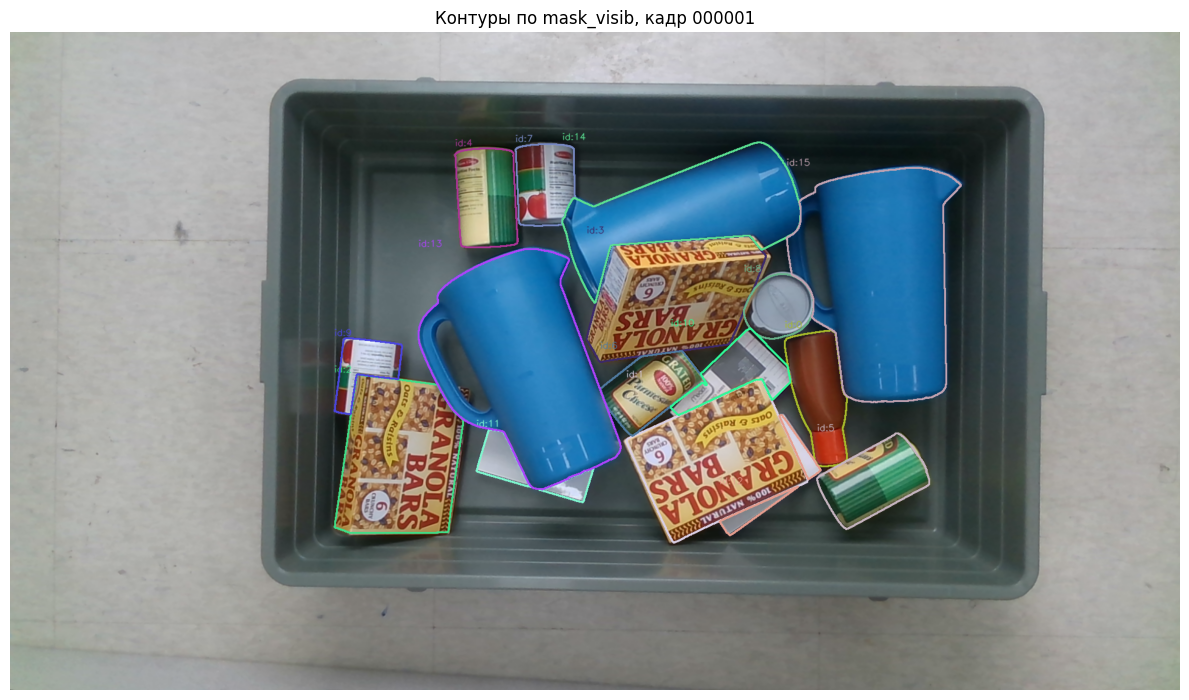

In [13]:
from pathlib import Path
import subprocess
import sys
import tempfile

import cv2
import matplotlib.pyplot as plt

scene_dir = Path("dataset_fragment (example)")
first_id = sorted((scene_dir / "rgb").glob("*.png"))[0].stem

with tempfile.TemporaryDirectory() as tmp_dir:
    out_path = Path(tmp_dir) / f"objects_contours_{first_id}.png"
    subprocess.run(
        [
            sys.executable,
            str(Path("utils/visualize_objects_from_mask_visib.py").resolve()),
            "--scene-dir",
            str(scene_dir.resolve()),
            "--image-id",
            first_id,
            "--out",
            str(out_path.resolve()),
        ],
        check=True,
    )
    rgb = cv2.cvtColor(cv2.imread(str(out_path)), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"Контуры по mask_visib, кадр {first_id}")
plt.tight_layout()
plt.show()

Создание 2-х датасетов для детекции из исходного с наложением дефектов на случайные объекты

RGB dataset: /home/vladimir/Документы/Проекты/Личные/defects_detection/two_base_datasets (example)/defects_rgb_det
Depth dataset: /home/vladimir/Документы/Проекты/Личные/defects_detection/two_base_datasets (example)/defects_depth_heat_det
Split sizes: train=36, valid=10, test=6
Кадр (defects_rgb_det): dataset_fragment (example)_000001.png
RGB:
  shape: (1080, 1920, 3), dtype: uint8
  min / max: 0, 255
Кадр (defects_depth_heat_det): dataset_fragment (example)_000001.png
Depth heat (RGB):
  shape: (1080, 1920, 3), dtype: uint8
  min / max : 0, 255


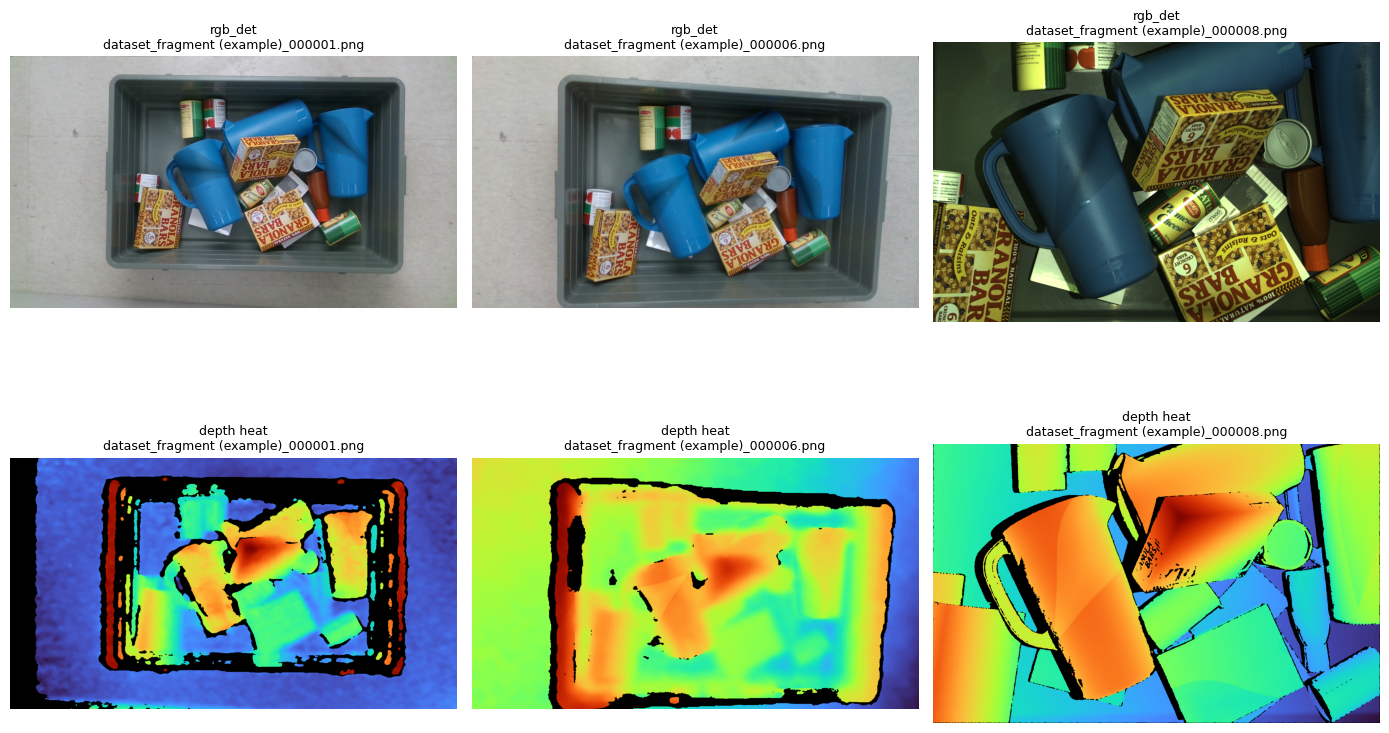

In [34]:
from pathlib import Path
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt

FIXED_DS_SEED = 177

proj = Path(".").resolve()
out = proj / "two_base_datasets (example)"

subprocess.run(
    [
        sys.executable,
        str(proj / "utils/generate_detection_datasets.py"),
        "--scenes-root",
        str(proj),
        "--output-root",
        str(out),
        "--seed",
        str(FIXED_DS_SEED),
        "--overwrite",
    ],
    check=True,
)

rgb_dir = out / "defects_rgb_det/train/images"
depth_dir = out / "defects_depth_heat_det/train/images"
rgbs = sorted(rgb_dir.glob("*.png"))[:3]
heats = sorted(depth_dir.glob("*.png"))[:3]

rgb0 = cv2.cvtColor(cv2.imread(str(rgbs[0]), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
heat0 = cv2.cvtColor(cv2.imread(str(heats[0]), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

print(f"Кадр (defects_rgb_det): {rgbs[0].name}")
print("RGB:")
print(f"  shape: {rgb0.shape}, dtype: {rgb0.dtype}")
print(f"  min / max: {rgb0.min()}, {rgb0.max()}")
print(f"Кадр (defects_depth_heat_det): {heats[0].name}")
print("Depth heat (RGB):")
print(f"  shape: {heat0.shape}, dtype: {heat0.dtype}")
print(f"  min / max : {heat0.min()}, {heat0.max()}")

samples = (
    [plt.imread(str(p)) for p in rgbs],
    [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) for p in heats],
)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for j in range(3):
    axes[0, j].imshow(samples[0][j])
    axes[0, j].set_title(f"rgb_det\n{rgbs[j].name}", fontsize=9)
    axes[0, j].axis("off")
    axes[1, j].imshow(samples[1][j])
    axes[1, j].set_title(f"depth heat\n{heats[j].name}", fontsize=9)
    axes[1, j].axis("off")
plt.tight_layout()
plt.show()


Объяснение процесса наложения дефектов на объекты (generate_detection_datasets и модуль apply_realistic_dents).

Общее
1) На каждом кадре в цикле делается несколько попыток, на каждой попытке случайно выбирается число объектов для деформирования - 1, 2 или 3
2) Кандидаты - это маски объектов из папки mask_visib для данного номера кадра. Маска с суммой пикселей < 250 отбрасывается как слишком маленькая
3) Из оставшихся выбирается не больше 3 объектов с приоритетом на большую площадь маски (сумма единиц по бинарной маске)
4) На каждый из выбранных объектов добавляется ровно один дефект, затем RGB-кадр преобразуется (warp, тени и затемнение, смешивание с оригиналом), и получается общая маска дефекта
5) По маске строятся прямоугольники формата YOLO через внешние контуры и bounding box. Если площадь прямоугольника < 25, он отбрасывается. В итоге должно получиться число областей от 1 до 3. Если ровно три прямоугольника, сравниваются их площади - если наименьшая меньше 1/3 наибольшей, попытка отбраковывается
6) Если за все попытки нужное качество не достигнуто, запускается запасной вариант с фиксированными двумя объектами, а в файле разметки сохраняются не больше 2-х первых bbox
7) Перед генерацией кадры перемешиваются по фиксированному seed и делятся примерно в пропорции 70 процентов train, 20 процентов validation, остальное - test. Для каждого кадра сохраняется разметка в  .txt файле

RGB

8) К уже искажённому после "вмятин" кадру в зоне маски добавляется мягкое затемнение - профиль задаётся через расстояние до границы маски и сглаживание (Gaussian), затем результат сохраняется (обычное трёхканальное PNG, порядок каналов как при записи через OpenCV - BGR)

Depth

9) К каждому пикселю с глубиной > 0 добавляется значение по формуле 0.075 * span * profile_d, где span - разница между максимальной и минимальной (валидной) глубиной на этом кадре, а profile_d - плавный профиль по той же маске дефекта, что использовалась для RGB, с собственными коэффициентами смеси маски и расстояния и отдельным сглаживанием. Значения обрезаются по верхней границе формата uint16
10) После этого строится цветная карта-псевдоцвет (Turbo) и изображение сохраняется

Данный подход для генерации дефектов (вмятин) был подобран путем проведения нескольких экспериментов. Некоторые версии можно увидеть в папке result_images (first_experiment.png и second_experiment.png)


Далее представлен пример создания датасета с 4-х канальными изображениями. То есть таким образом мы объединяем RGB и Depth информацию

Built /home/vladimir/Документы/Проекты/Личные/defects_detection/two_base_datasets (example)/defects_rgbd_4ch_det: 52 fused PNGs + paired labels
train: images=36
valid: images=10
test: images=6
total images: 52

dataset_fragment (example)_000001.png
shape=(1080, 1920, 4), dtype=uint8, channels=4
pixel[540, 960]=[66, 65, 57, 204]


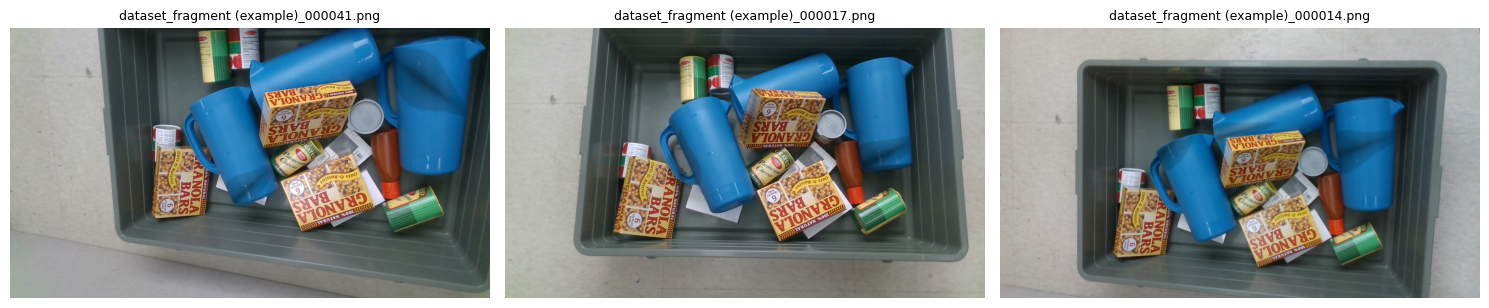

In [4]:
from pathlib import Path
import random
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

proj = Path(".").resolve()
out = proj / "two_base_datasets (example)"
ds_root = out / "defects_rgbd_4ch_det"

subprocess.run(
    [
        sys.executable,
        str(proj / "utils/build_rgbd_4channel_dataset.py"),
        "--rgb-root", str(out / "defects_rgb_det"),
        "--depth-root", str(out / "defects_depth_heat_det"),
        "--output-root", str(ds_root),
        "--overwrite",
    ],
    check=True,
)

all_images = []
for split in ("train", "valid", "test"):
    images = sorted((ds_root / split / "images").glob("*.png"))
    all_images.extend(images)
    print(f"{split}: images={len(images)}")
print(f"total images: {len(all_images)}")

sample_path = all_images[0]
arr = cv2.imread(str(sample_path), cv2.IMREAD_UNCHANGED)
channels = 1 if arr.ndim == 2 else arr.shape[2]
y, x = arr.shape[0] // 2, arr.shape[1] // 2
pixel = arr[y, x]
pixel_full = pixel.tolist() if isinstance(pixel, np.ndarray) else int(pixel)

print(f"\n{sample_path.name}")
print(f"shape={arr.shape}, dtype={arr.dtype}, channels={channels}")
print(f"pixel[{y}, {x}]={pixel_full}")

show_paths = random.sample(all_images, k=min(3, len(all_images)))
fig, axes = plt.subplots(1, len(show_paths), figsize=(5 * len(show_paths), 4))
if len(show_paths) == 1:
    axes = [axes]
for ax, p in zip(axes, show_paths):
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    rgb = cv2.cvtColor(img[..., :3], cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(p.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
